**示例**

In [68]:
import SimpleITK as sitk

image_path = "/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image"

In [69]:
import matplotlib.pyplot as plt
import os
import glob

image_list = glob.glob(os.path.join(image_path, "*.nii.gz"))
image_list

['/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/20.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/09.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/27.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/08.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/06.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/40.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/04.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/02.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/10.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/34.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/25.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/21.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/train/image/23.nii.gz',
 '/data2/songwei/Data/raw/Dataset012_BrainVessel/tr

In [70]:
ex_image = sitk.ReadImage(image_list[0])
ex_array = sitk.GetArrayFromImage(ex_image)

In [75]:
import numpy as np

percentile_99 = np.percentile(ex_array, 99.9)
print(percentile_99, np.mean(ex_array), np.std(ex_array))

365.0 65.88396432664659 50.32029813832915


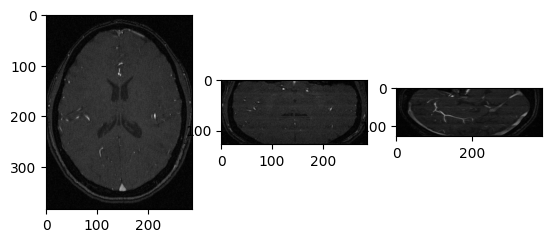

In [72]:
plt.subplot(1, 3, 1)
plt.imshow(ex_array[64, :, :], cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(ex_array[:, 192, :], cmap="gray")
plt.subplot(1, 3, 3)
plt.imshow(ex_array[:, :, 144], cmap="gray")
plt.show()

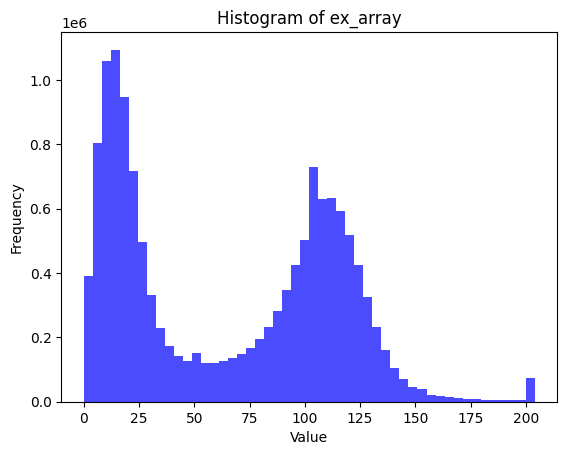

: 

In [76]:
import matplotlib.pyplot as plt

# Plot histogram
plt.hist(np.clip(ex_array, 0, np.percentile(ex_array, 99.5)).flatten(), bins=50, color='blue', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of ex_array')
plt.show()

**查看每一个的 size 和最大最小值**

In [15]:
size_list = []
max_min_list = []
mean_std = []
for image in image_list:
    ex_image = sitk.ReadImage(image)
    ex_array = sitk.GetArrayFromImage(ex_image)
    size_list.append(ex_array.shape)
    max_min_list.append([ex_array.max(), ex_array.min()])
    mean_std.append([ex_array.mean(), ex_array.std()])

In [16]:
size_list, max_min_list

([(128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288),
  (128, 384, 288)],
 [[968, 0],
  [998, 0],
  [803, 0],
  [955, 0],
  [866, 0],
  [1030, 0],
  [1114, 0],
  [1162, 0],
  [1016, 0],
  [916, 0],
  [872, 0],
  [896, 0],
  [826, 0],
  [739, 0],
  [1021, 0],
  [895, 0],
  [967, 0],
  [889, 0],
  [987, 0],
  [932, 0],
  [1011, 0],
  [1271, 0]])

In [17]:
ex_array = (ex_array - ex_array.mean()) / ex_array.std()

In [22]:
# 输出 ex_array 的分位数
import numpy as np

np.percentile(ex_array, [0, 25, 50, 75, 99.5])

array([-1.2771269 , -0.95802996, -0.10150657,  0.88937343,  2.61921478])

In [23]:
mean_std = np.array(mean_std)

In [25]:
mean_std.mean(axis=0)

(array([71.37061846, 50.70134319]), array([5.15371792, 3.63768102]))

In [6]:
import numpy as np
import pandas as pd

# 给定的列表
data_list = [
    "M001/T7/0644.jpg\n",
    "M001/T2/0547.jpg\n",
    "F018/T2/0336.jpg\n",
    "M011/T7/1984.jpg\n",
]

# 解析用户信息
users = [item.split("/")[0] for item in data_list]

# 初始化矩阵
n = len(users)
matrix = np.ones((n, n), dtype=int)

# 填充矩阵
for i in range(n):
    for j in range(n):
        if i != j:
            if users[i] == users[j]:
                matrix[i, j] = 1
            else:
                matrix[i, j] = 0

# 将矩阵转换为 DataFrame 以便展示
df_matrix = pd.DataFrame(matrix)
df_matrix

,0,1,2,3
0,1,1,0,0
1,1,1,0,0
2,0,0,1,0
3,0,0,0,1


In [2]:
import torch
import torchio


def test_random_elastic_deformation():
    """Test the RandomElasticDeformation transform."""

    # Define input tensors
    input = torch.randn(1, 32, 32, 32)
    gt = torch.randint(0, 2, (1, 32, 32, 32))

    # Define transformation parameters
    control_points = 7
    displacement = 7

    # Create the transform
    transform = torchio.RandomElasticDeformation(
        num_control_points=control_points, max_displacement=displacement
    )

    # Create a subject and apply the transformation
    subject = torchio.Subject(
        tensor=torchio.ScalarImage(tensor=input), label=torchio.LabelMap(tensor=gt)
    )
    transformed_subject = transform(subject)

    # Assertions
    assert transformed_subject["tensor"].shape == subject["tensor"].shape
    assert transformed_subject["label"].shape == subject["label"].shape
    assert not torch.equal(transformed_subject["tensor"].data, subject["tensor"].data)

    # Optional: Visualize the original and transformed images
    # import matplotlib.pyplot as plt
    # plt.imshow(input[0, :, :, 16], cmap='gray')
    # plt.show()
    # plt.imshow(transformed_subject['tensor'][0, :, :, 16], cmap='gray')
    # plt.show()


if __name__ == "__main__":
    test_random_elastic_deformation()

/home/yhwu/miniconda3/envs/sw/lib/python3.10/site-packages/torchio/transforms/augmentation/spatial/random_elastic_deformation.py:303: RuntimeWarning: The maximum displacement is larger than the coarse grid spacing for dimensions: [0, 1, 2], so folding may occur. Choose fewer control points or a smaller maximum displacement
  self.parse_free_form_transform(


In [11]:
import torch

m = torch.nn.Conv2d(3, 3, 7, 1, 9, dilation=3)
x = torch.rand(1, 3, 21, 21)
m(x).shape

torch.Size([1, 3, 21, 21])

Epoch 0:
Batch 0, Learning Rate 0.001072
Batch 1, Learning Rate 0.001144
Batch 2, Learning Rate 0.0012160000000000003
Batch 3, Learning Rate 0.0012880000000000003
Batch 4, Learning Rate 0.0013600000000000003
Batch 5, Learning Rate 0.0014320000000000005
Batch 6, Learning Rate 0.0015040000000000006
Batch 7, Learning Rate 0.0015760000000000006
Batch 8, Learning Rate 0.0016480000000000006
Batch 9, Learning Rate 0.0017200000000000006
Epoch 1:
Batch 0, Learning Rate 0.0017920000000000008
Batch 1, Learning Rate 0.0018640000000000009
Batch 2, Learning Rate 0.001936000000000001
Batch 3, Learning Rate 0.002008000000000001
Batch 4, Learning Rate 0.002080000000000001
Batch 5, Learning Rate 0.002152000000000001
Batch 6, Learning Rate 0.002224000000000001
Batch 7, Learning Rate 0.002296000000000001
Batch 8, Learning Rate 0.002368000000000001
Batch 9, Learning Rate 0.002440000000000001
Epoch 2:
Batch 0, Learning Rate 0.0025120000000000016
Batch 1, Learning Rate 0.0025840000000000017
Batch 2, Learning

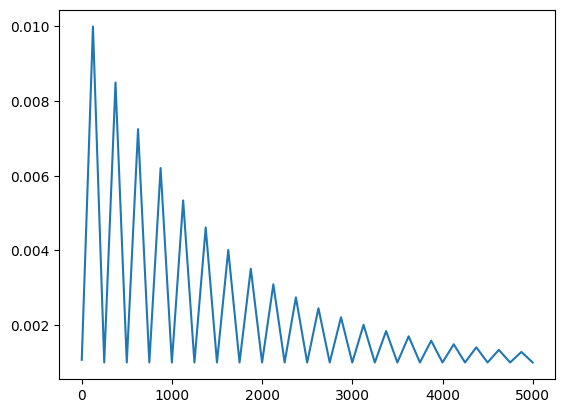

In [46]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import CyclicLR
import matplotlib.pyplot as plt

# 假设我们有一个简单的模型和损失函数
model = torch.nn.Linear(10, 1)
loss_fn = torch.nn.MSELoss()

# 定义一个优化器
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 定义一个CyclicLR调度器
scheduler = CyclicLR( 
    optimizer,
    base_lr=0.001,
    max_lr=0.01,
    step_size_up=500*10//40,
    mode="triangular2",
    scale_fn=lambda x: (1 / (1.2 **  (x - 1))),
)

lr = []
# 模拟训练过程
for epoch in range(500):
    print(f"Epoch {epoch}:")
    for batch in range(10):
        # 假设这里进行了一次前向传播和反向传播
        loss = loss_fn(model(torch.randn(10, 10)), torch.randn(10))

        # 更新权重
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 调整学习率
        scheduler.step()

        # 打印当前的学习率
        print(f"Batch {batch}, Learning Rate {scheduler.get_last_lr()[0]}")
        lr.append(scheduler.get_last_lr()[0])

plt.plot(lr)
plt.show()

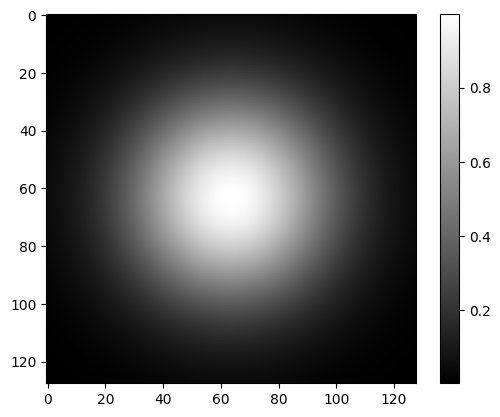

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Define the size of the image
size = (128, 128, 128)

# Create a Gaussian distribution with a large center and smaller surroundings
x = np.linspace(-5, 5, size[0])
y = np.linspace(-5, 5, size[1])
z = np.linspace(-5, 5, size[2])
x, y, z = np.meshgrid(x, y, z)
d = np.sqrt(x ** 2 + y ** 2 + z ** 2)

# Create the Gaussian distribution
sigma, mu = 4.0, 0.0
g = np.exp(-((d - mu) ** 2 / (2.0 * sigma ** 2)))

# Plot the Gaussian distribution
plt.imshow(g[:, :, 64], cmap="gray")
plt.colorbar()
plt.show()


In [1]:
import torch

state_dict = torch.load(
    "/data2/songwei/Segment/checkpoints/baselinev7/epoch=290-valid_loss=0.6326.ckpt"
)['state_dict']

In [11]:
for k in list(state_dict.keys()):
    if 'weight' in k:
        print(k, state_dict[k].mean(), state_dict[k].std())
    if 'bias' in k:
        print(k, state_dict[k].mean())

model.conv.conv_list.0.0.weight tensor(0.0031, device='cuda:2') tensor(0.1603, device='cuda:2')
model.conv.conv_list.0.0.bias tensor(-0.0085, device='cuda:2')
model.conv.conv_list.1.0.weight tensor(-0.0093, device='cuda:2') tensor(0.0868, device='cuda:2')
model.conv.conv_list.1.0.bias tensor(0.0167, device='cuda:2')
model.conv.conv_list.2.0.weight tensor(-0.0074, device='cuda:2') tensor(0.0873, device='cuda:2')
model.conv.conv_list.2.0.bias tensor(0.0384, device='cuda:2')
model.encoders.0.extractor.0.conv_list.0.0.weight tensor(-0.0130, device='cuda:2') tensor(0.0928, device='cuda:2')
model.encoders.0.extractor.0.conv_list.0.0.bias tensor(-0.0093, device='cuda:2')
model.encoders.0.extractor.0.conv_list.1.0.weight tensor(-0.0123, device='cuda:2') tensor(0.0928, device='cuda:2')
model.encoders.0.extractor.0.conv_list.1.0.bias tensor(-0.0004, device='cuda:2')
model.encoders.0.extractor.0.conv_list.2.0.weight tensor(-0.0067, device='cuda:2') tensor(0.0933, device='cuda:2')
model.encoders.0

(-0.3, 0.3)

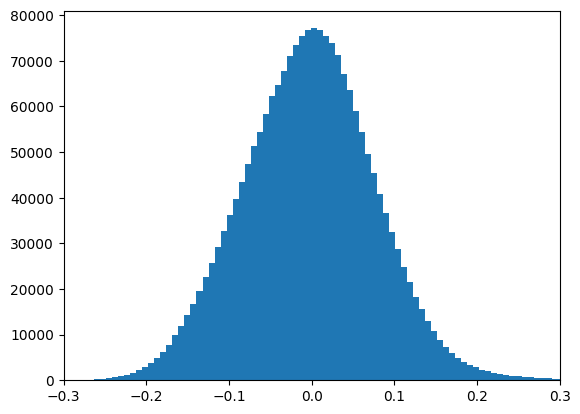

In [29]:
import numpy as np

state_dict['model.decoders.0.upsample.conv_list.2.0.weight'].flatten().shape

exmaple = state_dict['model.encoders.1.extractor.1.conv_list.2.0.weight'].flatten().cpu().numpy()
example = np.clip(exmaple, np.percentile(exmaple, 0.5), np.percentile(exmaple, 99.5))
import matplotlib.pyplot as plt
plt.hist(exmaple, bins=100)
plt.xlim(-0.3, 0.3)